# COGS 108 - EDA Checkpoint

## Authors

- Shannon Chen: Project administration, Conceptualization, Methodology
- Lianna Lim: Conceptualization, Software, Writing
- Niroop Krishnakumar: Analysis, Data Curation, Visualization
- Lina Seto: Software, Data Cleaning, Writing - review & editing
- Adwin Sujin: Analysis, Background research, Visualization, Writing

# Research Question

Does prenatal exposure to air pollution levels of PM2.5 (µg/m³) have differential effects on infant birth weight across racial and ethnic groups in California counties in 2023?



## Background and Prior Work

Our project examines whether prenatal exposure to fine particulate air pollution (PM2.5, µg/m³) is associated with differences in infant birth weight across racial and ethnic groups in California. We focus on identifying whether these effects vary by racial groups and how socioeconomic inequities may shape those differences. Birth weight disparities already exist across racial and ethnic groups in the United States. For example, non-Hispanic Black infants are nearly twice as likely to be born with low birth weight compared to non-Hispanic White infants even after accounting for other risk factors.<a name="cite_ref-4"></a>[<sup>4</sup>](#cite_note-4)

According to the NIH, women have a “20% increase in oxygen consumption, a 40% to 50% increase in minute ventilation, and a 40% increase in cardiac output” when they are pregnant.<a name="cite_ref-1a"></a>[<sup>1</sup>](#cite_note-1) This leads us to believe that pregnant women are more vulnerable to air pollution due to their increased intake and circulation of the particles. Moreover, an NIH study found that maternally inhaled carbonaceous air pollution particles can cross the placenta and then translocate into human fetal organs during gestation.<a name="cite_ref-1b"></a>[<sup>1</sup>](#cite_note-1) These studies suggest that air pollutants reach fetuses while they are in the womb. Since air pollutants are linked to a number of heart and lung problems, we are interested in investigating whether babies’ birth weights are affected by particulate exposure and whether this exposure exacerbates existing racial and ethnic disparities.

Since air pollution is a major environmental health concern, fine particulate matter (especially PM2.5, particles ≤2.5 micrometers) can penetrate deep into the lungs and enter the bloodstream. Pregnancy is a particularly sensitive period to the effects of fine particulate matter because fetal growth depends on consistent oxygen and nutrient delivery. A 2024 systematic review and meta-analysis examining prenatal exposure to PM2.5 and low birth weight pooled results from multiple cohort studies and found that exposure during pregnancy was significantly associated with an increased likelihood of low birth weight across trimesters.<a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2) These findings support the hypothesis that higher levels of particulate air pollution can negatively impact fetal growth.

Although there is convincing evidence that air pollution affects birth weight, there is limited research investigating whether the magnitude of impact differs across racial and ethnic groups. According to the CDC, “multiple studies have examined the relationship between PM2.5 and low birth weight, [but] few studies have been in a statewide representative sample or assessed for effect modification by poverty or race/ethnicity on that relationship.”<a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3) Because a gap remains in understanding how air pollution interacts with racial and socioeconomic disparities, our project analyzes the relationship among these variables to address this deficiency.

1. <a name="cite_note-1"></a> [^](#cite_ref-1a) Aguilera, J., et al. (2023). Air pollution and pregnancy. Journal of Allergy and Clinical Immunology, 151(2), 123–132. Retrieved from https://pmc.ncbi.nlm.nih.gov/articles/PMC10843016/
2. <a name="cite_note-2"></a> [^](#cite_ref-2) Parasin, N., et al. (2024). Prenatal PM2.5 exposure and its association with low birth weight: Systematic review and meta-analysis. PubMed Central. Retrieved from https://pmc.ncbi.nlm.nih.gov/articles/PMC11280910/
3. <a name="cite_note-3"></a> [^](#cite_ref-3) Lee, J., Costello, S., Balmes, J. R., & Holm, S. M. (2022). The association between ambient PM2.5 and low birth weight in California. International Journal of Environmental Research and Public Health. Retrieved from https://stacks.cdc.gov/view/cdc/231299
4. <a name="cite_note-4"></a> [^](#cite_ref-4) Womack, L. S., et al. CDC National Center for Health Statistics Data Brief: Singleton low birthweight rates by race and Hispanic origin; Almeida, J., et al. Racial/Ethnic Inequities in Low Birth Weight and Preterm Birth. Retrieved from https://www.cdc.gov/nchs/data/databriefs/db306.pdf

# Hypothesis


We predict that prenatal exposure to air pollution levels of PM2.5 (µg/m³) will have differing effects on infant birth weight across racial and ethnic groups in California. We have seen evidence of prenatal exposure to air pollution being negatively associated with infant birth weights due to the increased air particle intake by pregnant women and the permeability of the placenta to pollutants. Additionally, multiple previous NIH studies have reported negative associations between birth weight and PM2.5. We predict that this association will be different across different racial and ethnic groups, specifically that non-White groups will have a stronger negative association than White groups, due to socioeconomic resources and access to protective measures, difference in exposure levels and frequency, existing birthweight disparities, and potential genetic susceptibility.

## Data

### Data overview
- Dataset #1
  - Dataset Name: US EPA Annual Concentration by Monitor 2023
  - Link to the dataset: https://aqs.epa.gov/aqsweb/airdata/download_files.html
  - Number of observations: 82,387
  - Number of variables: 55
  - Description of the variables most relevant to this project:
    We will filter the data to only California. We will keep location variables such as latitude, longitude, address, and county name. We will also use parameter name (pollutant), metric used (ex: daily mean), units of measurement, observation count, arithmetic mean, and arithmetic standard deviation. We will further filter to only PM2.5 rows and group by county to compute county-level average PM2.5 exposure.
  - Descriptions of any shortcomings this dataset has with respect to the project:
    Measurements are taken at monitoring sites rather than uniformly across counties, so some counties may have sparse coverage. Aggregating monitors into a county average may introduce measurement bias.

- Dataset #2
  - Dataset Name: California Department of Public Health Low Birthweight (2010–2023)
  - Link to the dataset: https://www.cdph.ca.gov/Programs/CFH/DMCAH/surveillance/Pages/Low-Birthweight.aspx 
  - Number of observations: 65,086
  - Number of variables: 10
  - Description of the variables most relevant to this project:
   The California Department of Public Health birth outcomes dataset (2010–2023) reports county-level annual birth statistics in California. We will keep every column, but key variables include County and Year, plus low birthweight rate, low birthweight births (count), and total live births (count). Low birthweight is defined categorically using the standard cutoff < 2,500 grams, and any additional outcome columns are typically reported as percentages or counts.
  - Descriptions of any shortcomings this dataset has with respect to the project:
   Some counties with very small populations are not recorded in this dataset according to the FAQ. However, most are.

In [2]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [3]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 

datafiles = [
    { 'url': 'https://drive.google.com/uc?export=download&id=1Dgryhppze6qC3NcPZocG9LRMVVCFXpLz', 'filename':'annual_conc_by_monitor_2023.csv'},
    { 'url': 'https://drive.google.com/uc?export=download&id=1yxdgjhxEBX-ZFty96xJwrJrZh25X2H0C', 'filename':'Data-Low-Birthweight.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:  50%|█████     | 1/2 [00:02<00:02,  2.92s/it]                         

Successfully downloaded: annual_conc_by_monitor_2023.csv



Overall Download Progress: 100%|██████████| 2/2 [00:04<00:00,  2.31s/it]                  

Successfully downloaded: Data-Low-Birthweight.csv


### US EPA Annual Concentration by Monitor 2023

The birthweight dataset contains county-level annual data from the California Department of Public Health. Key variables include County (geographic identifier) and Year (calendar year of recorded births). The main outcome variable is Low Birthweight Rate, measured in percent (%), representing the percentage of live births weighing less than 2,500 grams. The dataset also includes Low Birthweight Count (number of births under 2,500 grams) and Total Live Births (total number of births in that county and year), both measured as raw counts. Additional demographic breakdown variables (if present) represent subgroup-specific rates or counts and are reported either as percentages (%) or counts. All birth weight thresholds are based on the standard clinical definition of low birthweight (< 2,500 grams).
Many rows describe the same pollutant, but differ in the specific site/location and sometimes the metric used to measure it. Many of these descriptive variables are strings. The important numeric variables are the total number of observations, the arithmetic mean (average annual pollutant amount), and arithmetic standard deviation at each site. The units will be defined by the "units of measure" variable, but in general we expect it to be ug/m3. Using current NAAQS standards, any amount >9 ug/m3 is considered unhealthy chronic exposure. Historically, >12 ug/m3 has been the standard, so we will consider this as especially dangerous exposure.
Concerns involve bias; after all, some counties might have more monitoring sites than others, which could lead to us seeing more air pollution in certain areas and not so much in less-monitored counties.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
air_quality = pd.read_csv('data/00-raw/annual_conc_by_monitor_2023.csv')
air_quality.head(5)

,State Code,County Code,Site Num,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Sample Duration,...,75th Percentile,50th Percentile,10th Percentile,Local Site Name,Address,State Name,County Name,City Name,CBSA Name,Date of Last Change
0,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,1 HOUR,...,0.055,0.049,0.033,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",5/24/2024
1,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.051,0.044,0.028,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",5/24/2024
2,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.051,0.044,0.028,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",5/24/2024
3,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.051,0.045,0.028,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",5/24/2024
4,1,3,10,88101,3,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,1 HOUR,...,10.600,7.000,1.400,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",8/6/2024


In [6]:
# the dataset is already tidy: every attribute is one column, every datapoint is one row, there is one table for each type of data,
# and the data correspondsd to the other table by County Name

# data shape
air_quality.shape

(82378, 55)

In [7]:
# select columns of interest
keep_cols = ['County Name',
            'Metric Used', 'Units of Measure',
             'Observation Count', 'Arithmetic Mean', 'Arithmetic Standard Dev',
             'Null Data Count', 'Num Obs Below MDL', 'Completeness Indicator', 'Valid Day Count', 'Required Day Count']

# keep data about California only and remove state identifiers
air_quality_ca = air_quality[air_quality['State Name'] == 'California'].drop(columns=['State Code', 'State Name'])
# keep data about PM2.5 only and remove info about parameter which has been selected for PM2.5 already
air_quality_ca = air_quality_ca[air_quality_ca['Parameter Name'].str.contains('PM2.5')].drop(columns=['Parameter Name'])
# keep only columns of interest, details are in the markdown cell below
air_quality_ca = air_quality_ca[keep_cols]
air_quality_ca

,County Name,Metric Used,Units of Measure,Observation Count,Arithmetic Mean,Arithmetic Standard Dev,Null Data Count,Num Obs Below MDL,Completeness Indicator,Valid Day Count,Required Day Count
4512,Alameda,Observed Values,Micrograms/cubic meter (25 C),8262,0.372606,0.463840,498,0,Y,341,365
4513,Alameda,Observed Values,Micrograms/cubic meter (LC),8092,6.423752,5.898829,668,0,Y,348,365
4514,Alameda,Daily Mean,Micrograms/cubic meter (LC),333,6.380480,4.759544,0,0,Y,333,365
4515,Alameda,Daily Mean,Micrograms/cubic meter (LC),333,6.380480,4.759544,0,0,Y,333,365
4516,Alameda,Daily Mean,Micrograms/cubic meter (LC),333,6.380480,4.759544,0,0,Y,333,365
...,...,...,...,...,...,...,...,...,...,...,...
14014,Yolo,Quarterly Means of Daily Means,Micrograms/cubic meter (LC),300,7.710000,5.845717,0,0,N,300,365
14015,Yolo,Quarterly Means of Daily Means,Micrograms/cubic meter (LC),300,7.710000,5.845717,0,0,N,300,365
14016,Yolo,Quarterly Means of Daily Means,Micrograms/cubic meter (LC),298,7.654362,5.824307,0,0,N,300,365
14017,Yolo,Quarterly Means of Daily Means,Micrograms/cubic meter (LC),300,7.710000,5.845717,0,0,N,300,365


__Considering Columns of Interest__
- 'County Code': redundant with County Name (DROP)
- 'Site Num': less descriptive than site name (DROP)
- 'Parameter Code': redundant with Parameter Name (DROP)
- 'POC': metadata about moniter type (DROP)
- 'Latitude': location data, use county-level instead (DROP)
- 'Longitude': location data, use county-level instead (DROP)
- 'Datum': metadata about location (DROP)
- 'Parameter Name': pollutant data, already controlled for PM2.5 (DROP)
- 'Sample Duration': unrelated to question (DROP)
- 'Pollutant Standard': we will evaluate arithmetic mean instead (DROP)
- 'Metric Used': pollutant data (KEEP)
- 'Method Name': metadata about collection tools (DROP)
- 'Year': all 2023 (DROP)
- 'Units of Measure': pollutant data (KEEP)
- 'Event Type': unrelated to question (DROP)
- 'Observation Count': shows sample sizes (KEEP)
- 'Observation Percent': slightly redundant t observation count (DROP)
- 'Completeness Indicator': metadata on validity of dataset (KEEP)
- 'Valid Day Count': metadata on validity of dataset (KEEP)
- 'Required Day Count': metadata on validity of dataset (KEEP)
- 'Exceptional Data Count': unrelated to question (DROP)
- 'Null Data Count': indications about missing data (KEEP)
- 'Primary Exceedance Count': very sparse (DROP)
- 'Secondary Exceedance Count': very sparse (DROP)
- 'Certification Indicator': metadata on validity of dataset, not useful to analyzing question (DROP)
- 'Num Obs Below MDL': indications about missing data (KEEP)
- 'Arithmetic Mean': variable of interest (KEEP)
- 'Arithmetic Standard Dev': related to variable of interest (KEEP)
- '1st Max Value': unrelated to question (DROP)
- '1st Max DateTime': unrelated to question (DROP)
- '2nd Max Value': unrelated to question (DROP)
- '2nd Max DateTime': unrelated to question (DROP)
- '3rd Max Value': unrelated to question (DROP)
- '3rd Max DateTime': unrelated to question (DROP)
- '4th Max Value': unrelated to question (DROP)
- '4th Max DateTime': unrelated to question (DROP)
- '1st Max Non Overlapping Value': very sparse, unrelated to question (DROP)
- '1st NO Max DateTime': very sparse, unrelated to question (DROP)
- '2nd Max Non Overlapping Value': very sparse, unrelated to question (DROP)
- '2nd NO Max DateTime': very sparse, unrelated to question (DROP)
- '99th Percentile': slightly redundant to Primary Exceedance Count (DROP)
- '98th Percentile': slightly redundant to Primary Exceedance Count (DROP)
- '95th Percentile': slightly redundant to Primary Exceedance Count (DROP)
- '90th Percentile': slightly redundant to Primary Exceedance Count (DROP)
- '75th Percentile': redundant to Primary Exceedance Count (DROP)
- '50th Percentile': redundant to Primary Exceedance Count (DROP)
- '10th Percentile': redundant to Primary Exceedance Count (DROP)
- 'Local Site Name': redundant to address (DROP)
- 'Address': location data, use county-level instead (DROP)
- 'County Name': location data (KEEP)
- 'City Name': redundant to address, main focus is county (DROP)
- 'CBSA Name': redundant to address, main focus is county (DROP)
- 'Date of Last Change': unrelated to question (DROP)

In [8]:
air_quality_ca.info()
# there is no missing data in the chosen columns or rows

<class 'pandas.core.frame.DataFrame'>
Index: 3884 entries, 4512 to 14018
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   County Name              3884 non-null   object 
 1   Metric Used              3884 non-null   object 
 2   Units of Measure         3884 non-null   object 
 3   Observation Count        3884 non-null   int64  
 4   Arithmetic Mean          3884 non-null   float64
 5   Arithmetic Standard Dev  3884 non-null   float64
 6   Null Data Count          3884 non-null   int64  
 7   Num Obs Below MDL        3884 non-null   int64  
 8   Completeness Indicator   3884 non-null   object 
 9   Valid Day Count          3884 non-null   int64  
 10  Required Day Count       3884 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 364.1+ KB


In [9]:
# upon further inspection: drop 'Num Obs Below MDL' as the value is 0 for all entries 
# (gives positive indication on reliability of measurements)
air_quality_ca = air_quality_ca.drop(columns=['Num Obs Below MDL'])

air_quality_ca.head(5)

,County Name,Metric Used,Units of Measure,Observation Count,Arithmetic Mean,Arithmetic Standard Dev,Null Data Count,Completeness Indicator,Valid Day Count,Required Day Count
4512,Alameda,Observed Values,Micrograms/cubic meter (25 C),8262,0.372606,0.463840,498,Y,341,365
4513,Alameda,Observed Values,Micrograms/cubic meter (LC),8092,6.423752,5.898829,668,Y,348,365
4514,Alameda,Daily Mean,Micrograms/cubic meter (LC),333,6.380480,4.759544,0,Y,333,365
4515,Alameda,Daily Mean,Micrograms/cubic meter (LC),333,6.380480,4.759544,0,Y,333,365
4516,Alameda,Daily Mean,Micrograms/cubic meter (LC),333,6.380480,4.759544,0,Y,333,365


In [10]:
for col in air_quality_ca.select_dtypes(include='number').columns:
    print(f'{col} max: {air_quality_ca[col].max()}')
    print(f'{col} min: {air_quality_ca[col].min()}')
# the Arithmetic Mean min being negative should not be possible, indicating some sort of error in measurement there
# the Arithmetic Standard Dev max being extremely high in relation to the max mean is unusal, pointing to outliers
# the rest of the data does not seem unusual

Observation Count max: 8724
Observation Count min: 1
Arithmetic Mean max: 23.65
Arithmetic Mean min: -0.007
Arithmetic Standard Dev max: 79.256949
Arithmetic Standard Dev min: 0.0
Null Data Count max: 7278
Null Data Count min: 0
Valid Day Count max: 365
Valid Day Count min: 0
Required Day Count max: 365
Required Day Count min: 4


In [11]:
# further research indicates that these slight negative values are often due to noise, measuring error, 
# or very low levels and are typically treated as 0, so we will replace them with 0
air_quality_ca['Arithmetic Mean'] = np.maximum(air_quality_ca['Arithmetic Mean'], 0)
air_quality_ca

,County Name,Metric Used,Units of Measure,Observation Count,Arithmetic Mean,Arithmetic Standard Dev,Null Data Count,Completeness Indicator,Valid Day Count,Required Day Count
4512,Alameda,Observed Values,Micrograms/cubic meter (25 C),8262,0.372606,0.463840,498,Y,341,365
4513,Alameda,Observed Values,Micrograms/cubic meter (LC),8092,6.423752,5.898829,668,Y,348,365
4514,Alameda,Daily Mean,Micrograms/cubic meter (LC),333,6.380480,4.759544,0,Y,333,365
4515,Alameda,Daily Mean,Micrograms/cubic meter (LC),333,6.380480,4.759544,0,Y,333,365
4516,Alameda,Daily Mean,Micrograms/cubic meter (LC),333,6.380480,4.759544,0,Y,333,365
...,...,...,...,...,...,...,...,...,...,...
14014,Yolo,Quarterly Means of Daily Means,Micrograms/cubic meter (LC),300,7.710000,5.845717,0,N,300,365
14015,Yolo,Quarterly Means of Daily Means,Micrograms/cubic meter (LC),300,7.710000,5.845717,0,N,300,365
14016,Yolo,Quarterly Means of Daily Means,Micrograms/cubic meter (LC),298,7.654362,5.824307,0,N,300,365
14017,Yolo,Quarterly Means of Daily Means,Micrograms/cubic meter (LC),300,7.710000,5.845717,0,N,300,365


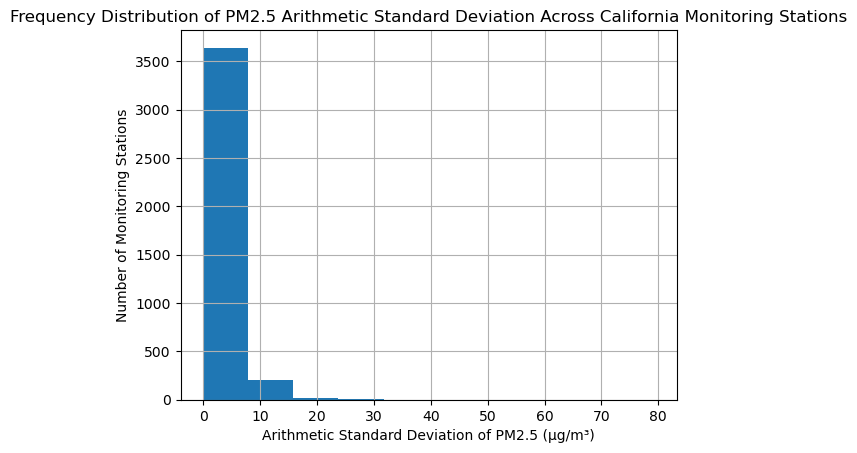

13210    79.256949
13208    76.554574
6092     50.116232
13194    42.530405
6082     35.325295
           ...    
5450      0.000000
8472      0.000000
5453      0.000000
5455      0.000000
13423     0.000000
Name: Arithmetic Standard Dev, Length: 3884, dtype: float64

In [12]:
air_quality_ca['Arithmetic Standard Dev'].hist()
plt.title('Frequency Distribution of PM2.5 Arithmetic Standard Deviation Across California Monitoring Stations')
plt.xlabel('Arithmetic Standard Deviation of PM2.5 (µg/m³)')
plt.ylabel('Number of Monitoring Stations')
plt.show()
air_quality_ca['Arithmetic Standard Dev'].sort_values(ascending=False)
# The standard deviation values above 40 are clearly outliers and erroneous, so we will remove them

In [13]:
# remove data with erroneous standard deviations (4 values)
air_quality_ca = air_quality_ca[air_quality_ca['Arithmetic Standard Dev'] < 40]
air_quality_ca

,County Name,Metric Used,Units of Measure,Observation Count,Arithmetic Mean,Arithmetic Standard Dev,Null Data Count,Completeness Indicator,Valid Day Count,Required Day Count
4512,Alameda,Observed Values,Micrograms/cubic meter (25 C),8262,0.372606,0.463840,498,Y,341,365
4513,Alameda,Observed Values,Micrograms/cubic meter (LC),8092,6.423752,5.898829,668,Y,348,365
4514,Alameda,Daily Mean,Micrograms/cubic meter (LC),333,6.380480,4.759544,0,Y,333,365
4515,Alameda,Daily Mean,Micrograms/cubic meter (LC),333,6.380480,4.759544,0,Y,333,365
4516,Alameda,Daily Mean,Micrograms/cubic meter (LC),333,6.380480,4.759544,0,Y,333,365
...,...,...,...,...,...,...,...,...,...,...
14014,Yolo,Quarterly Means of Daily Means,Micrograms/cubic meter (LC),300,7.710000,5.845717,0,N,300,365
14015,Yolo,Quarterly Means of Daily Means,Micrograms/cubic meter (LC),300,7.710000,5.845717,0,N,300,365
14016,Yolo,Quarterly Means of Daily Means,Micrograms/cubic meter (LC),298,7.654362,5.824307,0,N,300,365
14017,Yolo,Quarterly Means of Daily Means,Micrograms/cubic meter (LC),300,7.710000,5.845717,0,N,300,365


In [14]:
for col in air_quality_ca.select_dtypes(include='number').columns:
    print(f'{col} max: {air_quality_ca[col].max()}')
    print(f'{col} min: {air_quality_ca[col].min()}')
# now, the data does not seem to be unusual

Observation Count max: 8724
Observation Count min: 1
Arithmetic Mean max: 23.65
Arithmetic Mean min: 0.0
Arithmetic Standard Dev max: 35.325295
Arithmetic Standard Dev min: 0.0
Null Data Count max: 7278
Null Data Count min: 0
Valid Day Count max: 365
Valid Day Count min: 0
Required Day Count max: 365
Required Day Count min: 4


In [15]:
# shape of cleaned data
air_quality_ca.shape

(3880, 10)

In [16]:
# our metric of interest will be Observed Values measured by Micrograms/cubic meter (LC)
air_quality_ca = air_quality_ca[air_quality_ca['Units of Measure'] == 'Micrograms/cubic meter (LC)']
air_quality_ca = air_quality_ca[air_quality_ca['Metric Used'] == 'Observed Values']
air_quality_ca

,County Name,Metric Used,Units of Measure,Observation Count,Arithmetic Mean,Arithmetic Standard Dev,Null Data Count,Completeness Indicator,Valid Day Count,Required Day Count
4513,Alameda,Observed Values,Micrograms/cubic meter (LC),8092,6.423752,5.898829,668,Y,348,365
4554,Alameda,Observed Values,Micrograms/cubic meter (LC),8602,6.479772,5.843729,158,Y,363,365
4602,Alameda,Observed Values,Micrograms/cubic meter (LC),8511,6.910116,6.463004,248,Y,360,365
4640,Alameda,Observed Values,Micrograms/cubic meter (LC),8515,8.782971,7.840665,245,Y,361,365
4681,Alameda,Observed Values,Micrograms/cubic meter (LC),3474,6.998273,5.003367,5286,N,160,365
...,...,...,...,...,...,...,...,...,...,...
13976,Yolo,Observed Values,Micrograms/cubic meter (LC),8602,6.144699,5.989389,158,Y,360,365
13977,Yolo,Observed Values,Micrograms/cubic meter (LC),360,6.083056,4.528814,0,Y,360,365
13992,Yolo,Observed Values,Micrograms/cubic meter (LC),7231,7.724934,8.001244,1529,Y,304,365
13993,Yolo,Observed Values,Micrograms/cubic meter (LC),7176,7.660535,7.963025,1529,Y,304,365


In [17]:
# for future analysis, we will not need the columns representing data validity: Null Data Count, Completeness Indicator, 
# Valid Day Count, and Required Day Count

# As we have controlled for the Metric Used and Unit of Measure, we can remove these from our dataframe as well
air_quality_ca = air_quality_ca[['County Name', 'Observation Count', 'Arithmetic Mean', 'Arithmetic Standard Dev']]
air_quality_ca

,County Name,Observation Count,Arithmetic Mean,Arithmetic Standard Dev
4513,Alameda,8092,6.423752,5.898829
4554,Alameda,8602,6.479772,5.843729
4602,Alameda,8511,6.910116,6.463004
4640,Alameda,8515,8.782971,7.840665
4681,Alameda,3474,6.998273,5.003367
...,...,...,...,...
13976,Yolo,8602,6.144699,5.989389
13977,Yolo,360,6.083056,4.528814
13992,Yolo,7231,7.724934,8.001244
13993,Yolo,7176,7.660535,7.963025


In [18]:
# take the mean PM2.5 levels per county
mean_pm25 = air_quality_ca.groupby('County Name')['Arithmetic Mean'].mean().reset_index()
mean_pm25

,County Name,Arithmetic Mean
0,Alameda,6.981371
1,Butte,1.345509
2,Calaveras,5.630351
3,Colusa,11.384635
4,Contra Costa,8.201825
5,Del Norte,1.044456
6,El Dorado,0.248197
7,Fresno,0.939286
8,Glenn,6.679587
9,Humboldt,11.764652


###  California Department of Public Health: Low Birthweight 

The birthweight dataset contains county-level annual data from the California Department of Public Health. Key variables include County (geographic identifier) and Year (calendar year of recorded births). The main outcome variable is Low Birthweight Rate, measured in percent (%), representing the percentage of live births weighing less than 2,500 grams. The dataset also includes Low Birthweight Count (number of births under 2,500 grams) and Total Live Births (total number of births in that county and year), both measured as raw counts. Additional demographic breakdown variables (if present) represent subgroup-specific rates or counts and are reported either as percentages (%) or counts. All birth weight thresholds are based on the standard clinical definition of low birthweight (< 2,500 grams).

In [19]:
birthweight = pd.read_csv('data/00-raw/Data-Low-Birthweight.csv')
birthweight.head(5)

,Indicator Name,Geography,Year,Category,Subcategory,Numerator,Denominator,Percent,Lower 95% Confidence Limit,Upper 95% Confidence Limit
0,Low Birthweight,United States,2007-2009,Total Population,Total population,NaN,NaN,NaN,NaN,NaN
1,Low Birthweight,California,2007-2009,Total Population,Total population,112221.0,1644226.0,6.83,6.79,6.86
2,Low Birthweight,Alameda,2007-2009,Total Population,Total population,4437.0,62803.0,7.06,6.87,7.27
3,Low Birthweight,Alpine,2007-2009,Total Population,Total population,0.0,30.0,0.00,0.00,0.00
4,Low Birthweight,Amador,2007-2009,Total Population,Total population,43.0,877.0,4.90,3.66,6.54


In [20]:
# the dataset is already tidy: every attribute is one column, every datapoint is one row, there is one table for each type of data,
# and the data correspondsd to the other table by geography (county names)

# data shape
birthweight.shape

(65086, 10)

In [21]:
# keep only data on 2023 to match air quality data
birthweight_23 = birthweight[birthweight['Year'].str.contains('2023')]
# remove country-wide and state-wide values, only focusing on CA counties
birthweight_23 = birthweight_23[birthweight_23['Geography'] != 'United States']
birthweight_23 = birthweight_23[birthweight_23['Geography'] != 'California']
birthweight_23

,Indicator Name,Geography,Year,Category,Subcategory,Numerator,Denominator,Percent,Lower 95% Confidence Limit,Upper 95% Confidence Limit
56724,Low Birthweight,Alameda,2023,Total Population,Total population,1304.0,16193.0,8.05,7.64,8.48
56725,Low Birthweight,Alpine,2023,Total Population,Total population,0.0,3.0,0.00,0.00,0.00
56726,Low Birthweight,Amador,2023,Total Population,Total population,25.0,309.0,8.09,5.54,11.67
56727,Low Birthweight,Butte,2023,Total Population,Total population,143.0,2040.0,7.01,5.98,8.20
56728,Low Birthweight,Calaveras,2023,Total Population,Total population,26.0,380.0,6.84,4.71,9.84
...,...,...,...,...,...,...,...,...,...,...
63581,Low Birthweight,Tulare,2021-2023,Race Alone or in Combination and Ethnicity,White alone or in combination,1360.0,18759.0,7.25,6.89,7.63
63582,Low Birthweight,Tuolumne,2021-2023,Race Alone or in Combination and Ethnicity,White alone or in combination,89.0,1267.0,7.02,5.74,8.57
63583,Low Birthweight,Ventura,2021-2023,Race Alone or in Combination and Ethnicity,White alone or in combination,1396.0,21738.0,6.42,6.10,6.76
63584,Low Birthweight,Yolo,2021-2023,Race Alone or in Combination and Ethnicity,White alone or in combination,243.0,4311.0,5.64,4.99,6.37


In [22]:
# keep all columns, reasoning in the markdown cell below
# rename columns Numerator, Denominator, Percent for clarity
birthweight_23 = birthweight_23.rename(columns={'Numerator':'Number Low Birthweight', 
                                       'Denominator':'Number Live Births',
                                       'Percent':'Percent Low Birthweight'})
birthweight_23

,Indicator Name,Geography,Year,Category,Subcategory,Number Low Birthweight,Number Live Births,Percent Low Birthweight,Lower 95% Confidence Limit,Upper 95% Confidence Limit
56724,Low Birthweight,Alameda,2023,Total Population,Total population,1304.0,16193.0,8.05,7.64,8.48
56725,Low Birthweight,Alpine,2023,Total Population,Total population,0.0,3.0,0.00,0.00,0.00
56726,Low Birthweight,Amador,2023,Total Population,Total population,25.0,309.0,8.09,5.54,11.67
56727,Low Birthweight,Butte,2023,Total Population,Total population,143.0,2040.0,7.01,5.98,8.20
56728,Low Birthweight,Calaveras,2023,Total Population,Total population,26.0,380.0,6.84,4.71,9.84
...,...,...,...,...,...,...,...,...,...,...
63581,Low Birthweight,Tulare,2021-2023,Race Alone or in Combination and Ethnicity,White alone or in combination,1360.0,18759.0,7.25,6.89,7.63
63582,Low Birthweight,Tuolumne,2021-2023,Race Alone or in Combination and Ethnicity,White alone or in combination,89.0,1267.0,7.02,5.74,8.57
63583,Low Birthweight,Ventura,2021-2023,Race Alone or in Combination and Ethnicity,White alone or in combination,1396.0,21738.0,6.42,6.10,6.76
63584,Low Birthweight,Yolo,2021-2023,Race Alone or in Combination and Ethnicity,White alone or in combination,243.0,4311.0,5.64,4.99,6.37


__Columns of Interest__
- 'Indicator Name': indicate category of birthweight (KEEP)
- 'Geography': county or state name (KEEP)
- 'Year': show specificity of 2021-2023 or 2023 (KEEP)
- 'Category': information about race and other groupings (KEEP)
- 'Subcategory': added information on race and other groupings (KEEP)
- 'Number Low Birthweight': variable of interest (KEEP)
- 'Number Live Births': shows total number of births (KEEP)
- 'Percent Low Birthweight': percent, quick look at proportion of low birthweights (KEEP)
- 'Lower 95% Confidence Limit': show range of percent (KEEP)
- 'Upper 95% Confidence Limit': show range of percent (KEEP)

In [23]:
birthweight_23.info()
# there is missingness in Number Low Birthweights, Percent Low Birthweight, Lower 95% Confidence Limit, and Upper 95% Confidence Limit

# missingness was explained in the data description as indicating that Number Low Birthweights < 10
# so it is reasonable to fill na with 0 (assuming 95% CI used normal approximation)

<class 'pandas.core.frame.DataFrame'>
Index: 4234 entries, 56724 to 63585
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Indicator Name              4234 non-null   object 
 1   Geography                   4234 non-null   object 
 2   Year                        4234 non-null   object 
 3   Category                    4234 non-null   object 
 4   Subcategory                 4234 non-null   object 
 5   Number Low Birthweight      3113 non-null   float64
 6   Number Live Births          4234 non-null   float64
 7   Percent Low Birthweight     3113 non-null   float64
 8   Lower 95% Confidence Limit  3113 non-null   float64
 9   Upper 95% Confidence Limit  3113 non-null   float64
dtypes: float64(5), object(5)
memory usage: 363.9+ KB


In [24]:
birthweight_23 = birthweight_23.fillna(0)
birthweight_23

,Indicator Name,Geography,Year,Category,Subcategory,Number Low Birthweight,Number Live Births,Percent Low Birthweight,Lower 95% Confidence Limit,Upper 95% Confidence Limit
56724,Low Birthweight,Alameda,2023,Total Population,Total population,1304.0,16193.0,8.05,7.64,8.48
56725,Low Birthweight,Alpine,2023,Total Population,Total population,0.0,3.0,0.00,0.00,0.00
56726,Low Birthweight,Amador,2023,Total Population,Total population,25.0,309.0,8.09,5.54,11.67
56727,Low Birthweight,Butte,2023,Total Population,Total population,143.0,2040.0,7.01,5.98,8.20
56728,Low Birthweight,Calaveras,2023,Total Population,Total population,26.0,380.0,6.84,4.71,9.84
...,...,...,...,...,...,...,...,...,...,...
63581,Low Birthweight,Tulare,2021-2023,Race Alone or in Combination and Ethnicity,White alone or in combination,1360.0,18759.0,7.25,6.89,7.63
63582,Low Birthweight,Tuolumne,2021-2023,Race Alone or in Combination and Ethnicity,White alone or in combination,89.0,1267.0,7.02,5.74,8.57
63583,Low Birthweight,Ventura,2021-2023,Race Alone or in Combination and Ethnicity,White alone or in combination,1396.0,21738.0,6.42,6.10,6.76
63584,Low Birthweight,Yolo,2021-2023,Race Alone or in Combination and Ethnicity,White alone or in combination,243.0,4311.0,5.64,4.99,6.37


In [25]:
# there do not seem to be any concerning outliers
for col in ['Percent Low Birthweight', 'Lower 95% Confidence Limit', 'Upper 95% Confidence Limit']:
    print(f'{col} min: {birthweight_23[col].min()}')
    print(f'{col} max: {birthweight_23[col].max()}')

Percent Low Birthweight min: 0.0
Percent Low Birthweight max: 100.0
Lower 95% Confidence Limit min: 0.0
Lower 95% Confidence Limit max: 95.45
Upper 95% Confidence Limit min: 0.0
Upper 95% Confidence Limit max: 100.0


In [26]:
# shape of cleaned data
birthweight_23.shape

(4234, 10)

In [27]:
# choose for only the race-related subcategories
race_based = ['Hispanic of any race', 'Multiracial alone',
       'Black alone', 'AIAN alone', 'Asian alone', 'NHPI alone',
       'White alone', 'Other alone', 'Unknown alone','AIAN alone or in combination',
       'Asian alone or in combination', 'Black alone or in combination',
       'NHPI alone or in combination', 'White alone or in combination']
birthweight_race = birthweight_23[(birthweight_23['Subcategory'].isin(race_based))]
birthweight_race

,Indicator Name,Geography,Year,Category,Subcategory,Number Low Birthweight,Number Live Births,Percent Low Birthweight,Lower 95% Confidence Limit,Upper 95% Confidence Limit
56928,Low Birthweight,Alameda,2021-2023,Race Alone and Ethnicity,Hispanic of any race,945.0,13712.0,6.89,6.48,7.33
56929,Low Birthweight,Alameda,2021-2023,Race Alone and Ethnicity,Multiracial alone,119.0,1535.0,7.75,6.52,9.20
56930,Low Birthweight,Alameda,2021-2023,Race Alone and Ethnicity,Black alone,503.0,3949.0,12.74,11.73,13.81
56931,Low Birthweight,Alameda,2021-2023,Race Alone and Ethnicity,AIAN alone,0.0,54.0,0.00,0.00,0.00
56932,Low Birthweight,Alameda,2021-2023,Race Alone and Ethnicity,Asian alone,1475.0,17064.0,8.64,8.23,9.07
...,...,...,...,...,...,...,...,...,...,...
63581,Low Birthweight,Tulare,2021-2023,Race Alone or in Combination and Ethnicity,White alone or in combination,1360.0,18759.0,7.25,6.89,7.63
63582,Low Birthweight,Tuolumne,2021-2023,Race Alone or in Combination and Ethnicity,White alone or in combination,89.0,1267.0,7.02,5.74,8.57
63583,Low Birthweight,Ventura,2021-2023,Race Alone or in Combination and Ethnicity,White alone or in combination,1396.0,21738.0,6.42,6.10,6.76
63584,Low Birthweight,Yolo,2021-2023,Race Alone or in Combination and Ethnicity,White alone or in combination,243.0,4311.0,5.64,4.99,6.37


In [28]:
# upon further inspection for analysis, we can remove Category (redundant to Subcategory), 
# Lower 95% Confidence Limit, Upper 95% Confidence Limit (both not giving added information to percent), and
# Year (only has 2021-2023 category now)
birthweight_race = birthweight_race[['Indicator Name', 'Geography', 'Subcategory', 'Number Low Birthweight', 
                                     'Number Live Births', 'Percent Low Birthweight']]
birthweight_race

,Indicator Name,Geography,Subcategory,Number Low Birthweight,Number Live Births,Percent Low Birthweight
56928,Low Birthweight,Alameda,Hispanic of any race,945.0,13712.0,6.89
56929,Low Birthweight,Alameda,Multiracial alone,119.0,1535.0,7.75
56930,Low Birthweight,Alameda,Black alone,503.0,3949.0,12.74
56931,Low Birthweight,Alameda,AIAN alone,0.0,54.0,0.00
56932,Low Birthweight,Alameda,Asian alone,1475.0,17064.0,8.64
...,...,...,...,...,...,...
63581,Low Birthweight,Tulare,White alone or in combination,1360.0,18759.0,7.25
63582,Low Birthweight,Tuolumne,White alone or in combination,89.0,1267.0,7.02
63583,Low Birthweight,Ventura,White alone or in combination,1396.0,21738.0,6.42
63584,Low Birthweight,Yolo,White alone or in combination,243.0,4311.0,5.64


In [29]:
# capture the categories of white vs non-white that we will compare in a column
birthweight_race['Race Group'] = birthweight_race['Subcategory'].str.contains('White').map({True: 'White', False: 'Non-White'})
birthweight_race

/tmp/ipykernel_477/70969813.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  birthweight_race['Race Group'] = birthweight_race['Subcategory'].str.contains('White').map({True: 'White', False: 'Non-White'})


,Indicator Name,Geography,Subcategory,Number Low Birthweight,Number Live Births,Percent Low Birthweight,Race Group
56928,Low Birthweight,Alameda,Hispanic of any race,945.0,13712.0,6.89,Non-White
56929,Low Birthweight,Alameda,Multiracial alone,119.0,1535.0,7.75,Non-White
56930,Low Birthweight,Alameda,Black alone,503.0,3949.0,12.74,Non-White
56931,Low Birthweight,Alameda,AIAN alone,0.0,54.0,0.00,Non-White
56932,Low Birthweight,Alameda,Asian alone,1475.0,17064.0,8.64,Non-White
...,...,...,...,...,...,...,...
63581,Low Birthweight,Tulare,White alone or in combination,1360.0,18759.0,7.25,White
63582,Low Birthweight,Tuolumne,White alone or in combination,89.0,1267.0,7.02,White
63583,Low Birthweight,Ventura,White alone or in combination,1396.0,21738.0,6.42,White
63584,Low Birthweight,Yolo,White alone or in combination,243.0,4311.0,5.64,White


In [30]:
# we will group by the county and racial group and take the average percent low birthweight for each
grouped_birthweight = birthweight_race.groupby(['Geography', 'Race Group'])['Percent Low Birthweight'].mean().reset_index()
grouped_birthweight

,Geography,Race Group,Percent Low Birthweight
0,Alameda,Non-White,7.390000
1,Alameda,White,5.710000
2,Alpine,Non-White,0.000000
3,Alpine,White,0.000000
4,Amador,Non-White,1.190769
...,...,...,...
111,Ventura,White,6.045000
112,Yolo,Non-White,3.758462
113,Yolo,White,5.655000
114,Yuba,Non-White,5.944615


### Merge DataFrames

In [31]:
# to find the mean PM2.5 level for each race group of each county
per_county = mean_pm25.merge(grouped_birthweight, left_on='County Name', right_on='Geography').drop(columns=['Geography'])
per_county

,County Name,Arithmetic Mean,Race Group,Percent Low Birthweight
0,Alameda,6.981371,Non-White,7.390000
1,Alameda,6.981371,White,5.710000
2,Butte,1.345509,Non-White,4.570000
3,Butte,1.345509,White,6.900000
4,Calaveras,5.630351,Non-White,0.938462
...,...,...,...,...
93,Tulare,1.172354,White,6.825000
94,Ventura,5.909050,Non-White,4.868462
95,Ventura,5.909050,White,6.045000
96,Yolo,7.067632,Non-White,3.758462


In [32]:
# to connect the observed level of PM2.5 for each datapoint to the racial groups
merge_df = air_quality_ca.merge(grouped_birthweight, left_on='County Name', right_on='Geography').drop(columns=['Geography'])
merge_df

,County Name,Observation Count,Arithmetic Mean,Arithmetic Standard Dev,Race Group,Percent Low Birthweight
0,Alameda,8092,6.423752,5.898829,Non-White,7.390000
1,Alameda,8092,6.423752,5.898829,White,5.710000
2,Alameda,8602,6.479772,5.843729,Non-White,7.390000
3,Alameda,8602,6.479772,5.843729,White,5.710000
4,Alameda,8511,6.910116,6.463004,Non-White,7.390000
...,...,...,...,...,...,...
4589,Yolo,7231,7.724934,8.001244,White,5.655000
4590,Yolo,7176,7.660535,7.963025,Non-White,3.758462
4591,Yolo,7176,7.660535,7.963025,White,5.655000
4592,Yolo,7231,7.724934,8.001244,Non-White,3.758462


In [33]:
# write to folder
import os
folder_path = "data/02-processed"
air_quality_ca.to_csv(os.path.join(folder_path, "air_quality_ca.csv"), index=False)
grouped_birthweight.to_csv(os.path.join(folder_path, "grouped_birthweight.csv"), index=False)
mean_pm25.to_csv(os.path.join(folder_path, "mean_pm25.csv"), index=False)
per_county.to_csv(os.path.join(folder_path, "per_county.csv"), index=False)
merge_df.to_csv(os.path.join(folder_path, "merge_df.csv"), index=False)

#### Transform PM2.5 `Arithmetic Mean` to Categorical
Using the current NAAQS standards by the US EPA, annual mean PM2.5 levels greater than 9 micrograms/cubic meter exceed the standard and will be considered `Unhealthy` chronic exposure.
Before this, we will also rename the `Arithmetic Mean` column to `PM2.5 Mean` for clarity.

In [34]:
# Load datasets
import pandas as pd
import numpy as np
per_county = pd.read_csv('data/02-processed/per_county.csv')
merge_df = pd.read_csv('data/02-processed/merge_df.csv')

# First let's quickly rename the columns
per_county = per_county.rename(columns={'Arithmetic Mean':'PM2.5 Mean'})
merge_df = merge_df.rename(columns={'Arithmetic Mean':'PM2.5 Mean'})

# Add a new categorical column to per_county and merge_df
per_county['PM2.5 Category'] = np.select( 
    [ 
        per_county['PM2.5 Mean'] <= 9, 
        per_county['PM2.5 Mean'] > 9 
    ], 
    ['Healthy','Unhealthy'],
    default = "Unhealthy"
)

merge_df['PM2.5 Category'] = np.select( 
    [ 
        merge_df['PM2.5 Mean'] <= 9, 
        merge_df['PM2.5 Mean'] > 9 
    ], 
    ['Healthy','Unhealthy'],
    default = "Unhealthy"
)

# Let's take a look at per_county now
per_county

,County Name,PM2.5 Mean,Race Group,Percent Low Birthweight,PM2.5 Category
0,Alameda,6.981371,Non-White,7.390000,Healthy
1,Alameda,6.981371,White,5.710000,Healthy
2,Butte,1.345509,Non-White,4.570000,Healthy
3,Butte,1.345509,White,6.900000,Healthy
4,Calaveras,5.630351,Non-White,0.938462,Healthy
...,...,...,...,...,...
93,Tulare,1.172354,White,6.825000,Healthy
94,Ventura,5.909050,Non-White,4.868462,Healthy
95,Ventura,5.909050,White,6.045000,Healthy
96,Yolo,7.067632,Non-White,3.758462,Healthy


In [35]:
# Write to folder again
import os
folder_path = "data/02-processed"
per_county.to_csv(os.path.join(folder_path, "per_county.csv"), index=False)
merge_df.to_csv(os.path.join(folder_path, "merge_df.csv"), index=False)

## Results

### Exploratory Data Analysis


In [36]:
# load in dfs

# air_quality_ca = pd.read_csv('data/02-processed/air_quality_ca.csv')
# grouped_birthweight = pd.read_csv('data/02-processed/grouped_birthweight.csv')
# mean_pm25 = pd.read_csv('data/02-processed/mean_pm25.csv')
per_county = pd.read_csv('data/02-processed/per_county.csv')
merge_df = pd.read_csv('data/02-processed/merge_df.csv')

#### Plotting Distributions of County-Level PM2.5 Exposure and Low Birthweight

Let's start with the county-level PM2.5 annual mean:

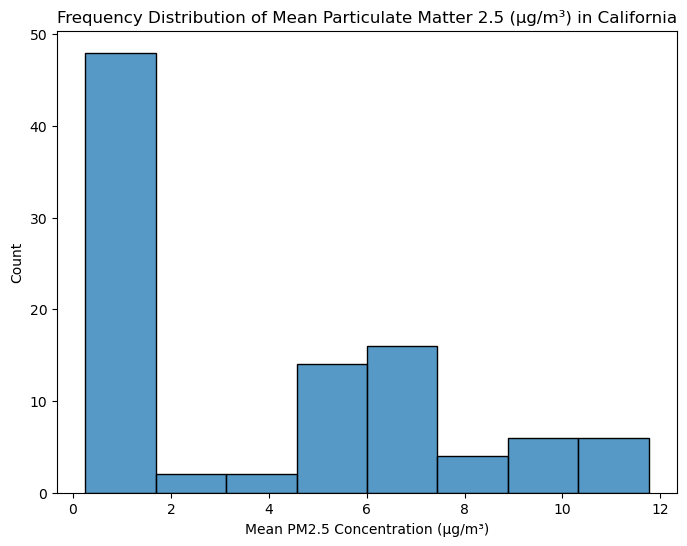

In [54]:
import seaborn as sns
plt.figure(figsize=(8,6))

sns.histplot(per_county["PM2.5 Mean"]) 
plt.title("Frequency Distribution of Mean Particulate Matter 2.5 (µg/m³) in California")
plt.xlabel("Mean PM2.5 Concentration (µg/m³)")
plt.ylabel("Count")
plt.show()

##### Analysis:
This histogram displays the distribution of mean PM2.5 air pollution levels across California counties. PM2.5 refers to any airborne particle smaller than 2.5 micrometers in size. While all counties are measuring the same category of particle, the concentration of those particles in the air varies by location. The x-axis shows the mean PM2.5 concentration in micrograms per cubic meter (µg/m³), indicating how many micrograms of fine 2.5 particles are present in one cubic meter of air. The y-axis shows the number of California counties at each concentration level. For example, there are 48 counties in California with a concentration of 0-1.75 micrograms of fine particles in every cubic meter of air in that area.

The graph displays a bimodal dsitribution, as there is a hump in the 0-1.75 µg/m³ range and a second hump in the 4.25-5.75 µg/m³ range. This indictes that our data could be representing two distinct populations. The two modes could represent the rural air pollution concentrations and urban air pollution concentrations.


Next is low birthweight percentages

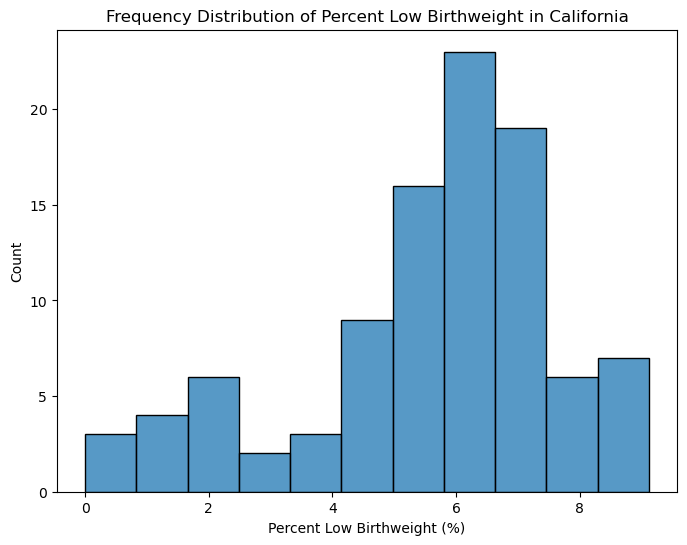

In [38]:
plt.figure(figsize=(8,6))

sns.histplot(per_county['Percent Low Birthweight'])

plt.title("Frequency Distribution of Percent Low Birthweight in California")
plt.xlabel("Percent Low Birthweight (%)")
plt.ylabel("Count")

plt.show()


#### Analysis
This histogram displays how California counties are distributed across different rates of low birthweight, which means the percentage of babies in that county that were born under 2,500g. The x-axis shows the percent of low birthweight and the y-axis shows the number of counties with that percentage. 

This histogram represents a slight bimodal distribution with a small cluster at 2% and a large cluster at 6%, indicating most counties in California have about 6% of their birthweight population.



### Plotting the Relationship Between PM2.5 and Low Birthweight

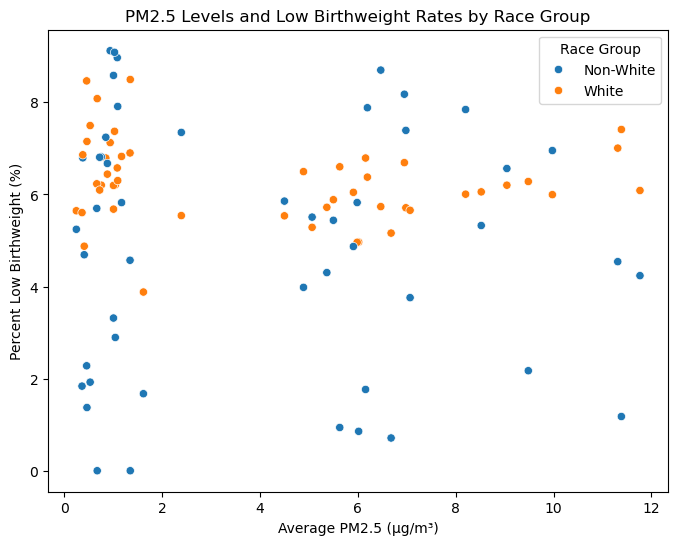

In [39]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=per_county,
    x='PM2.5 Mean',
    y='Percent Low Birthweight',
    hue='Race Group'
)

plt.title("PM2.5 Levels and Low Birthweight Rates by Race Group")
plt.xlabel("Average PM2.5 (µg/m³)")
plt.ylabel("Percent Low Birthweight (%)")

plt.legend(title="Race Group")

#### Analysis:
This scatter plot examines the relationship between average PM2.5 air pollution levels (measired in µg/m³) and percent low birthweight (babies born below 2,500 g) across California counties, comparing Non-White and White race groups. Both groups are heavily concentrated at lower PM2.5 levels (0–2 µg/m³) and reach up to a concentration of 12 µg/m³ . Despite this range, there is no clear linear trend between PM2.5 and low birthweight rates, suggesting that air pollution alone is not the primary driver of low birthweight outcomes. Notably, Non-White racial groups show far greater variability in birthweight rates (ranging from 0–9%) compared to White racial groups, which tend to cluster between 5–8%. This disparity points to the influence of broader social determinants of health like socioeconomic status, healthcare access, and systemic inequities that could be contributing factors beyond air pollution alone.


### Heatmap between White and Nonwhite Percent Low Birthweight and PM2.5 Mean

Text(0.5, 1.0, 'Correlation Heatmap: PM2.5 and Low Birthweight (Non-White)')

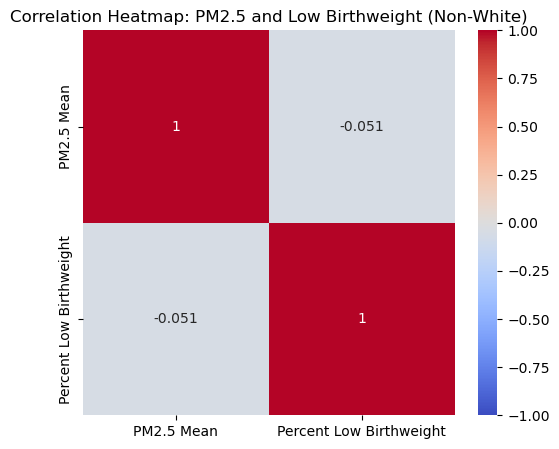

In [40]:

nonwhite = per_county[per_county['Race Group'] == 'Non-White']

corr_nonwhite = nonwhite[['PM2.5 Mean','Percent Low Birthweight']].corr()

plt.figure(figsize=(6,5))

sns.heatmap(corr_nonwhite, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.title("Correlation Heatmap: PM2.5 and Low Birthweight (Non-White)")


#### Analysis
This correlation heatmap examines the relationship between PM2.5 mean concentration and percent low birthweight among Non-White populations across California counties. The diagonal values of 1 simply represent each variable's perfect correlation with itself, which is expected. The key finding is the correlation coefficient of -0.051 between PM2.5 Mean and Percent Low Birthweight, which indicates a very weak negative relationship — meaning that as PM2.5 levels increase, low birthweight rates very slightly decrease, though this relationship is so close to zero that it is essentially negligible. The near-neutral gray color of the off-diagonal cells visually confirms this near-zero correlation. This suggests that for Non-White populations in California counties, PM2.5 air pollution levels alone have virtually no linear relationship with low birthweight rates.


Text(0.5, 1.0, 'Correlation Heatmap: PM2.5 and Low Birthweight (White)')

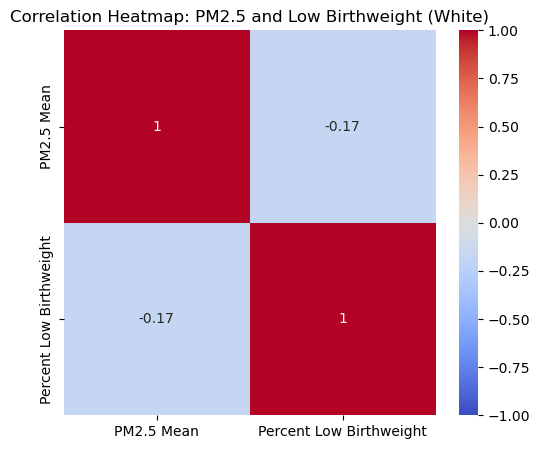

In [41]:
white = per_county[per_county['Race Group'] == 'White']

corr_white = white[['PM2.5 Mean','Percent Low Birthweight']].corr()

plt.figure(figsize=(6,5))

sns.heatmap(corr_white, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.title("Correlation Heatmap: PM2.5 and Low Birthweight (White)")


#### Analysis:
This correlation heatmap shows the relationship between average PM2.5 air pollution levels and the percent of low birthweight births among White populations across California counties. The diagonal values of 1 represent each variable’s perfect correlation with itself, which is expected in any correlation matrix.
The key value in this heatmap is the correlation coefficient of -0.17 between PM2.5 Mean and Percent Low Birthweight. This indicates a weak negative relationship, meaning that as PM2.5 levels increase, the percentage of low birthweight births among White populations slightly decreases. However, because this value is still close to zero, the relationship is very weak and likely not statistically meaningful.
The light blue color of the off-diagonal cell visually reinforces this weak relationship. Overall, this suggests that PM2.5 air pollution alone does not strongly explain variation in low birthweight rates among White populations in California counties, and that other factors such as socioeconomic conditions, healthcare access, or maternal health may play a larger role.



### Geospatial Analysis of PM2.5 Levels and White and Non-White Percent Low Birthweight



In [42]:
import geopandas as gpd

In [43]:
counties = gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_500k.zip")
ca_counties = counties[counties['STATEFP'] == '06']

In [44]:
white_per_county = per_county[per_county['Race Group'] == 'White']
non_white_per_county = per_county[per_county['Race Group'] != 'White']
ca_counties_white = ca_counties.merge(white_per_county, left_on='NAME', right_on='County Name', how='left')
ca_counties_non_white = ca_counties.merge(non_white_per_county, left_on='NAME', right_on='County Name', how='left')

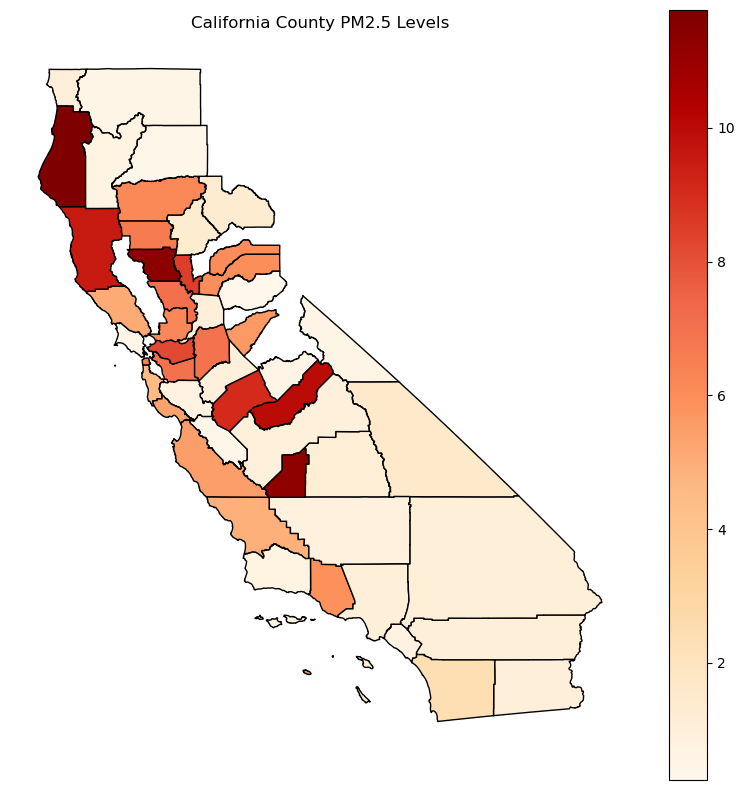

In [45]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 10))
ca_counties_white.plot(column='PM2.5 Mean', cmap='OrRd', legend=True, ax=ax, edgecolor='black')
ax.set_title("California County PM2.5 Levels")
ax.axis('off')
plt.show()

#### Analysis:

This choropleth map visualizes the average PM2.5 air pollution levels across counties in California. PM2.5 refers to fine particulate matter smaller than 2.5 micrometers, which can penetrate deep into the lungs and pose serious health risks.
Each county is shaded according to its average PM2.5 concentration, measured in micrograms per cubic meter (µg/m³). Darker red colors indicate higher pollution levels, while lighter colors represent lower concentrations of particulate matter.
The map shows that several counties in central and northern California experience higher PM2.5 concentrations, while many counties in the southern and inland regions appear to have lower average levels. These differences may reflect factors such as population density, industrial activity, wildfire exposure, and regional weather patterns that affect how pollutants accumulate in the atmosphere.
Visualizing pollution geographically helps highlight regional disparities in air quality, which is important for understanding potential environmental health risks across different communities.


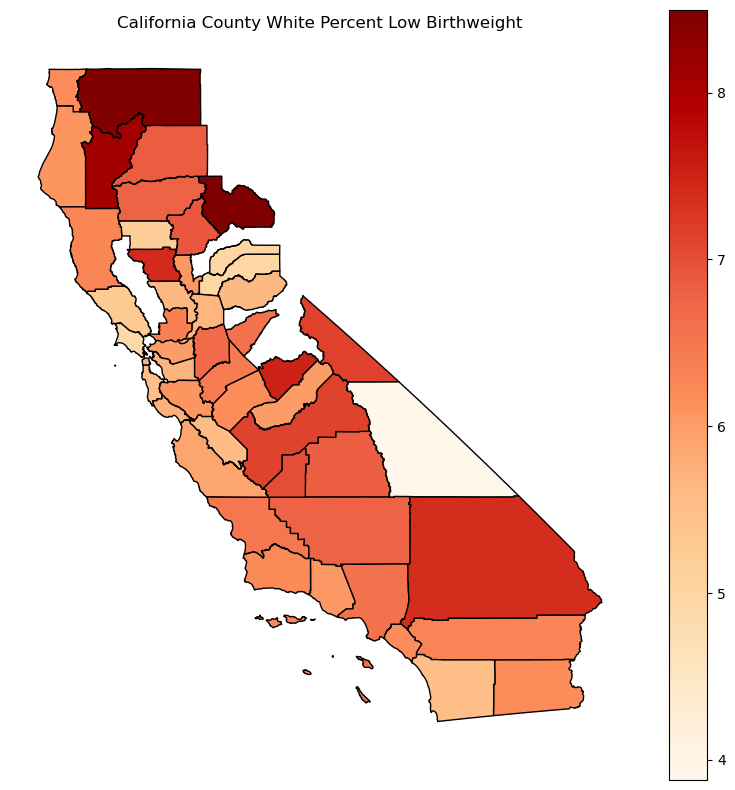

In [46]:
fig, ax = plt.subplots(figsize=(10, 10))
ca_counties_white.plot(column='Percent Low Birthweight', cmap='OrRd', legend=True, ax=ax, edgecolor='black')
ax.set_title("California County White Percent Low Birthweight")
ax.axis('off')
plt.show()

#### Analysis:
This choropleth map displays the percentage of low birthweight births among White populations across California counties. Low birthweight is defined as babies born weighing less than 2,500 grams, which can increase risks of developmental and health complications.
The color gradient represents the percent of births classified as low birthweight, with darker red shades indicating higher percentages and lighter colors indicating lower percentages. Most counties fall within a range of roughly 5–7 percent, suggesting that low birthweight rates among White populations are relatively consistent across many parts of the state.
However, some counties exhibit higher rates, which may reflect differences in local healthcare access, maternal health factors, socioeconomic conditions, or environmental exposures. Mapping these values geographically allows researchers to identify areas where birth outcomes may differ and where further investigation may be needed.



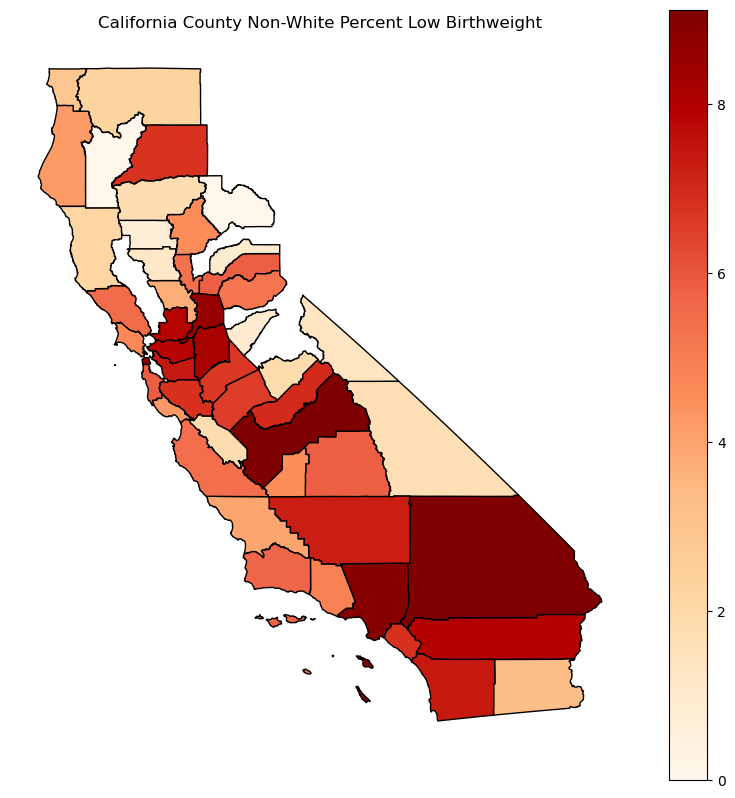

In [47]:
fig, ax = plt.subplots(figsize=(10, 10))
ca_counties_non_white.plot(column='Percent Low Birthweight', cmap='OrRd', legend=True, ax=ax, edgecolor='black')
ax.set_title("California County Non-White Percent Low Birthweight")
ax.axis('off')
plt.show()

#### Analysis: 

This map illustrates the percentage of low birthweight births among Non-White populations across California counties. As with the previous map, darker colors represent higher percentages of low birthweight births, while lighter colors indicate lower rates.
Compared to the White population map, the Non-White map shows greater variation in low birthweight percentages across counties, with several counties displaying higher values in the 7–9 percent range. This suggests that birth outcomes among Non-White populations may vary more widely across different regions.
These differences may be influenced by structural and social determinants of health, including disparities in healthcare access, socioeconomic status, environmental exposures, and systemic inequalities. Visualizing these geographic patterns helps highlight potential health disparities across racial groups, which is important for identifying areas where public health interventions may be most needed.


### Log Normalization 
Let's see the distribution of our `PM2.5` and `Percent Low Birthweight` variables when we log transform them:

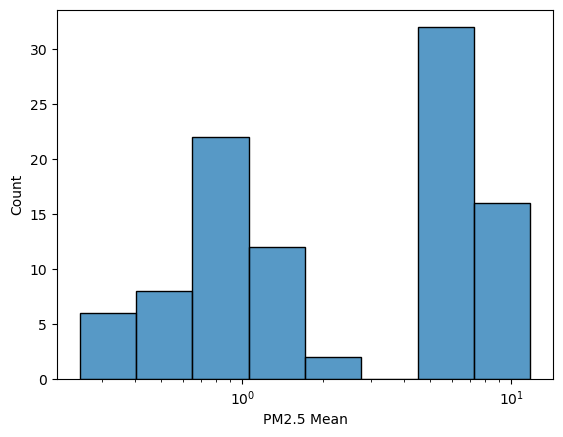

In [48]:
pm25_hist_log = sns.histplot(per_county['PM2.5 Mean'], log_scale=True)

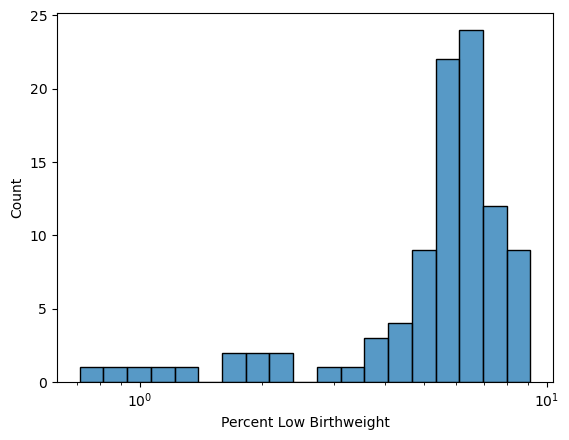

In [49]:
birthweight_hist_log = sns.histplot(per_county['Percent Low Birthweight'], log_scale=True)

These are not significantly better. We can see how `Percent Low Birthweight` is virtually the same, so we will leave it as is. Thus, we will make a log-transformed column for just `PM2.5 Mean` to see which produces better results when performing OLS regression. 

In [50]:
per_county["PM2.5 Mean Log"] = np.log10(per_county["PM2.5 Mean"] + 0.01)

### OLS Regression
Let's run OLS regression to confirm if there is any relationship between county-level PM2.5 mean levels and the percentage of low birthweights, and whether this affect differs by race group (white or non-white).
We'll test 3 models:
1. Predicting `Percent Low Birthweight` using `PM2.5 Mean` and `Race Group`
2. Predicting `Percent Low Birthweight` using `PM2.5 Mean Log` and `Race Group`
3. Predicting `Percent Low Birthweight` using `PM2.5 Mean`, `Race Group`, and their interaction

In [51]:
import statsmodels.formula.api as smf
model1 = smf.ols("Q('Percent Low Birthweight') ~ Q('PM2.5 Mean') + C(Q('Race Group'))", data=per_county).fit()
print(model1.summary())

                                 OLS Regression Results                                 
Dep. Variable:     Q('Percent Low Birthweight')   R-squared:                       0.109
Model:                                      OLS   Adj. R-squared:                  0.090
Method:                           Least Squares   F-statistic:                     5.806
Date:                          Thu, 05 Mar 2026   Prob (F-statistic):            0.00418
Time:                                  02:33:04   Log-Likelihood:                -205.85
No. Observations:                            98   AIC:                             417.7
Df Residuals:                                95   BIC:                             425.4
Df Model:                                     2                                         
Covariance Type:                      nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------

`PM2.5` does not seem to be statistically significant (p = 0.48), whereas `Race Group` is statistically significant with a p-value of 0.001.

In [52]:
model2 = smf.ols("Q('Percent Low Birthweight') ~ Q('PM2.5 Mean Log') + C(Q('Race Group'))", data=per_county).fit()
print(model2.summary())

                                 OLS Regression Results                                 
Dep. Variable:     Q('Percent Low Birthweight')   R-squared:                       0.107
Model:                                      OLS   Adj. R-squared:                  0.088
Method:                           Least Squares   F-statistic:                     5.690
Date:                          Thu, 05 Mar 2026   Prob (F-statistic):            0.00463
Time:                                  02:33:04   Log-Likelihood:                -205.95
No. Observations:                            98   AIC:                             417.9
Df Residuals:                                95   BIC:                             425.7
Df Model:                                     2                                         
Covariance Type:                      nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------

Logging `PM2.5` did not improve our model. Results are similar to model 1, but the adjusted R-squared is slightly worse.

In [53]:
model3 = smf.ols("Q('Percent Low Birthweight') ~ Q('PM2.5 Mean') * C(Q('Race Group'))", data=per_county).fit()
print(model3.summary())

                                 OLS Regression Results                                 
Dep. Variable:     Q('Percent Low Birthweight')   R-squared:                       0.109
Model:                                      OLS   Adj. R-squared:                  0.080
Method:                           Least Squares   F-statistic:                     3.830
Date:                          Thu, 05 Mar 2026   Prob (F-statistic):             0.0123
Time:                                  02:33:04   Log-Likelihood:                -205.85
No. Observations:                            98   AIC:                             419.7
Df Residuals:                                94   BIC:                             430.0
Df Model:                                     3                                         
Covariance Type:                      nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975

## Ethics

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

This project uses publicly available county-level data and does not involve human subjects or individual-level records. Because the data are not linked to specific people, informed consent is not applicable.

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

Our analysis is limited to California, which is generally wealthier and may have better healthcare access and stricter air quality regulations than other regions. As a result, our findings may not generalize beyond California. Additionally, county-level aggregation may hide within-county disparities, such as neighborhoods with higher pollution exposure or reduced access to prenatal care. Race and ethnicity categories are socially defined classifications that may not perfectly capture lived experiences or exposure patterns. We will avoid interpreting group differences as biological differences and instead frame results within structural and environmental contexts.

 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

All datasets are aggregated at the county level and reported as averages or rates (e.g., PM2.5, ozone levels, and birth outcome rates). Ethnicity variables are reported only as population-level statistics and cannot be traced to individuals. No personally identifiable information is collected or used, resulting in low privacy risk.

 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

Because the project analyzes outcomes across racial and ethnic groups, there is a risk of reinforcing harmful stereotypes if results are misinterpreted. We will avoid making causal claims about inherent group differences and use neutral and respectful language when reporting differences. We will emphasize structural factors such as socioeconomic conditions and access to healthcare and present uncertainty when interpreting results.

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?

The data used are entirely public and aggregated, so they do not require special security measures beyond standard academic data handling practices.

 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?

Because the project does not store personal or identifiable data, individual data removal requests are not applicable.

 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

Data will be retained only for the duration of the project and can be deleted after analysis is complete.

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?

County-level data may fail to capture the experiences of smaller or more vulnerable communities within counties, and race/ethnicity categories may mask heterogeneity within groups. We acknowledge that results cannot represent individual risk.

 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

Potential confounders include income, maternal age, access to prenatal care, housing quality, and occupational exposure. Observed associations between air pollution and birth outcomes may reflect broader structural inequality rather than pollution alone. We will interpret findings cautiously and avoid causal conclusions.

 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

Our visualizations and summaries will be clearly labeled and designed to reflect the data accurately, without exaggerating effect sizes or implying causation.

 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?

No personally identifiable information is included in the analysis or visualizations.

 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

The analysis process will be documented and reproducible, allowing future reviewers to understand and reassess the results if needed.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?
Race and ethnicity will not be used to predict individuals and will only be used as an analytical grouping variable to study environmental inequality.
 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?
We will compare model behavior across groups to ensure results are not driven by imbalance or measurement differences.
 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?
We will prioritize interpretable statistical measures such as confidence intervals and effect sizes over purely predictive accuracy metrics.
 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
Models will be limited to interpretable statistical analyses so conclusions can be explained in public health terms.
 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

We will clearly communicate that findings are correlational, limited to California, and based on aggregated county-level data, and that unmeasured confounders may influence observed patterns.

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed?
This project is academic and not deployed in a real-world decision system.
 - [X] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results?
We will include clear disclaimers to prevent misuse in policy or individual medical decisions.
 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
Not applicable because the project is not deployed.
 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?

There is a risk the analysis could be misinterpreted as causal or used to stigmatize groups. To mitigate this, conclusions will be framed as environmental inequity research and limitations will be emphasized prominently.


## Team Expectations 

- **Communication**
  - Communicate primarily through an iMessage group chat for quick updates and questions
  - Respond to messages by the end of the day to maintain steady progress
  - Hold a Zoom call every weekend to review progress, clarify responsibilities, and address concerns
- **Tone**
  - Maintain a respectful and professional tone in all group communication
  - Provide constructive criticism focused on improving the work rather than criticizing individuals
  - Remain open to feedback and willing to revise work based on group input
- **Decision Making**
  - Use a majority vote (3/5) when consensus cannot be reached
  - Ensure all members have an opportunity to share their perspective before voting
  - Clearly document decisions so expectations are aligned moving forward
- **Task expectations**
  - Assign specific roles and responsibilities for each deliverable ahead of time
  - Set clear deadlines and milestones for each task and update them as the project evolves
  - Communicate early if a task may be delayed so adjustments can be made collaboratively
- **When struggling**
  - Reach out to the group as soon as challenges arise, whether technical or scheduling related
  - Ask for help without hesitation to prevent small issues from becoming larger problems
  - Support teammates by sharing resources, feedback, and guidance when someone is struggling


## Project Timeline Proposal

| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 2/1  |  7:30 PM | Read & Think about COGS 108 expectations; brainstorm topics/questions  | Determine best form of communication; Discuss and decide on final project topic; discuss hypothesis; begin background research | 
| 2/3  |  11:59 PM |  Everyone complete assigned part of project proposal by 2/3 @midnight | Discuss ideal dataset(s) and ethics; draft project proposal | 
| 2/8  | 9:30 PM  | Edit, finalize, and submit proposal; Search for datasets  | Discuss Wrangling and possible analytical approaches; Assign group members to lead each specific part   |
| 2/16  | 9 PM  | Import & Wrangle Data; EDA | Review/Edit wrangling/EDA; Discuss Analysis Plan   |
| 2/18  | 9 PM  | Finalize 01-Data Checkpoint | Proofread Data Checkpoint 1 + push to GitHub   |
| 3/2  | 9 PM  | Finalize wrangling; Begin EDA | Review Wrangling; Discuss EDA and Analysis |
| 3/13  | 12 PM  | Complete analysis; Draft results/conclusion/discussion | Discuss/edit full project |
| 3/18  | Before 11:59 PM  | NA | Turn in Final Project & Group Project Surveys |